In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.utils.class_weight import compute_class_weight
from tqdm.auto import tqdm
import json
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
import mlflow
import mlflow.pytorch




In [202]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [203]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [204]:
EMBEDDING_DIM = 50
HIDDEN_DIM = 64
MAX_LEN = 50
BATCH_SIZE = 64
EPOCHS = 20
LEARNING_RATE = 1e-3

In [205]:
df = pd.read_csv("/kaggle/input/datasets/bjdhdhjdbd/twitter-data-sentiment/clean_data.csv")
df = df.dropna()
df.head()

,clean_text,category
0,family mormon never try explain still stare pu...,1.0
1,buddhism much lot compatible christianity espe...,1.0
2,seriously say thing first get complex explain ...,-1.0
3,learn want teach different focus goal not wrap...,0.0
4,benefit may want read live buddha live christ ...,1.0


In [206]:
df.shape

(199508, 2)

In [207]:
NUM_CLASSES = len(np.unique(df["category"]))
NUM_CLASSES

3

In [208]:
encoder = LabelEncoder()
df["category"] = encoder.fit_transform(df["category"])
np.unique(df["category"])

array([0, 1, 2])

In [209]:
X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"],
    df["category"],
    test_size=0.20,
    stratify=df["category"],
    random_state=SEED
)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train,
    y_train,
    test_size=0.10,
    stratify=y_train,
    random_state=SEED
)

In [211]:
weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
class_weights = torch.tensor(weights, dtype=torch.float32).to(device)

In [212]:
train_tokens = [
    sentence.split()
    for sentence in X_train
]

valid_tokens = [
    sentence.split()
    for sentence in X_valid
]

test_tokens = [
    sentence.split()
    for sentence in X_test
]

In [129]:
train_tokens[0]

['perhaps',
 'modi',
 'forgot',
 'tell',
 'nation',
 'minute',
 'congress',
 'could',
 'not',
 'year',
 'congratulation',
 'drdo',
 'scientiststell',
 'nation',
 'start',
 'project']

In [213]:
word2vec = Word2Vec(
    sentences=train_tokens,
    vector_size=EMBEDDING_DIM,
    window=3,
    min_count=15,
    workers=4,
    epochs=20
)

In [214]:
print(len(word2vec.wv))

9201


In [215]:
word2idx = {
    "<PAD>":0,
    "<UNK>":1
}

for word in word2vec.wv.index_to_key:

    word2idx[word] = len(word2idx)

word2idx

{'<PAD>': 0,
 '<UNK>': 1,
 'modi': 2,
 'not': 3,
 'india': 4,
 'but': 5,
 'say': 6,
 'people': 7,
 'bjp': 8,
 'like': 9,
 'get': 10,
 'congress': 11,
 'give': 12,
 'make': 13,
 'vote': 14,
 'one': 15,
 'election': 16,
 'time': 17,
 'narendra': 18,
 'take': 19,
 'year': 20,
 'indian': 21,
 'country': 22,
 'know': 23,
 'govt': 24,
 'come': 25,
 'want': 26,
 'good': 27,
 'even': 28,
 'see': 29,
 'think': 30,
 'dont': 31,
 'also': 32,
 'party': 33,
 'government': 34,
 'would': 35,
 'work': 36,
 'go': 37,
 'nation': 38,
 'rahul': 39,
 'modis': 40,
 'well': 41,
 'need': 42,
 'power': 43,
 'minister': 44,
 'support': 45,
 'gandhi': 46,
 'leader': 47,
 'thing': 48,
 'ask': 49,
 'pakistan': 50,
 'money': 51,
 'use': 52,
 'hai': 53,
 'win': 54,
 'credit': 55,
 'right': 56,
 'day': 57,
 'do': 58,
 'back': 59,
 'every': 60,
 'space': 61,
 'show': 62,
 'much': 63,
 'become': 64,
 'never': 65,
 'many': 66,
 'job': 67,
 'new': 68,
 'medium': 69,
 'call': 70,
 'prime': 71,
 'great': 72,
 'way': 73,
 '

In [216]:
idx2word = {
    idx:word
    for word,idx in word2idx.items()
}

idx2word

{0: '<PAD>',
 1: '<UNK>',
 2: 'modi',
 3: 'not',
 4: 'india',
 5: 'but',
 6: 'say',
 7: 'people',
 8: 'bjp',
 9: 'like',
 10: 'get',
 11: 'congress',
 12: 'give',
 13: 'make',
 14: 'vote',
 15: 'one',
 16: 'election',
 17: 'time',
 18: 'narendra',
 19: 'take',
 20: 'year',
 21: 'indian',
 22: 'country',
 23: 'know',
 24: 'govt',
 25: 'come',
 26: 'want',
 27: 'good',
 28: 'even',
 29: 'see',
 30: 'think',
 31: 'dont',
 32: 'also',
 33: 'party',
 34: 'government',
 35: 'would',
 36: 'work',
 37: 'go',
 38: 'nation',
 39: 'rahul',
 40: 'modis',
 41: 'well',
 42: 'need',
 43: 'power',
 44: 'minister',
 45: 'support',
 46: 'gandhi',
 47: 'leader',
 48: 'thing',
 49: 'ask',
 50: 'pakistan',
 51: 'money',
 52: 'use',
 53: 'hai',
 54: 'win',
 55: 'credit',
 56: 'right',
 57: 'day',
 58: 'do',
 59: 'back',
 60: 'every',
 61: 'space',
 62: 'show',
 63: 'much',
 64: 'become',
 65: 'never',
 66: 'many',
 67: 'job',
 68: 'new',
 69: 'medium',
 70: 'call',
 71: 'prime',
 72: 'great',
 73: 'way',
 7

In [217]:
VOCAB_SIZE = len(word2idx)

print(VOCAB_SIZE)

9203


In [218]:
embedding_matrix = np.zeros(
    (VOCAB_SIZE, EMBEDDING_DIM),
    dtype=np.float32
)
for word, idx in word2idx.items():

    if word in word2vec.wv:

        embedding_matrix[idx] = word2vec.wv[word]

In [219]:
embedding_matrix[2]

array([ 0.29953682,  0.2634241 , -0.13859232,  0.83851534, -0.5525608 ,
        0.32591316,  0.5534209 , -0.27879667,  0.58732504, -0.17764182,
        1.3825362 , -0.17736046, -0.98492754,  0.6254773 , -0.01457516,
       -0.07244713,  0.9451418 ,  0.1996436 ,  0.16047716, -0.3935224 ,
        0.43879238,  0.00661122, -0.24771804,  1.4440111 ,  1.4761124 ,
       -1.1375911 ,  1.2528912 ,  1.103663  ,  1.1795706 ,  0.69630563,
       -1.8695861 , -0.360638  , -0.20453605,  0.16311769, -0.6327225 ,
       -0.7006736 ,  0.7066997 , -0.8213507 ,  0.14648806,  0.71634656,
       -1.2014343 , -0.30179805, -0.8919645 , -0.39004186, -1.1917127 ,
        0.44676283, -0.04433589,  0.69270766,  0.40229842, -0.12625962],
      dtype=float32)

In [140]:
print(embedding_matrix.shape)

(9203, 50)


In [220]:
def encode_sentence(sentence):

    ids = []

    for word in sentence.split():

        ids.append(
            word2idx.get(word,1)
        )

    ids = ids[:MAX_LEN]

    ids += [0]*(MAX_LEN-len(ids))

    return ids

In [221]:
sample = encode_sentence(
    X_train.iloc[0]
)

print(sample)

[1515, 2, 2857, 102, 38, 745, 11, 125, 3, 20, 301, 120, 1, 38, 96, 334, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [222]:
class TextDataset(Dataset):

    def __init__(self, texts, labels):

        self.texts = texts.tolist()
        self.labels = labels.tolist()

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):

        sentence = encode_sentence(self.texts[idx])

        return (
            torch.tensor(sentence, dtype=torch.long),
            torch.tensor(self.labels[idx], dtype=torch.long)
        )

In [223]:
train_dataset = TextDataset(
    X_train,
    y_train
)

valid_dataset = TextDataset(
    X_valid,
    y_valid
)

test_dataset = TextDataset(
    X_test,
    y_test
)

In [224]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

In [225]:
x, y = next(iter(train_loader))

print(x.shape)
print(y.shape)

torch.Size([64, 50])
torch.Size([64])


In [226]:
class BiGRUClassifier(nn.Module):

    def __init__(
        self,
        embedding_matrix,
        hidden_size,
        num_classes,
        dropout=0.5,
        freeze_embedding=True
    ):

        super().__init__()

        vocab_size, embedding_dim = embedding_matrix.shape

        self.embedding = nn.Embedding.from_pretrained(
            torch.FloatTensor(embedding_matrix),
            freeze=freeze_embedding,
            padding_idx=0
        )

        self.gru = nn.GRU(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            batch_first=True,
            bidirectional=False
        )

        self.dropout = nn.Dropout(dropout)
        self.norm_64 = nn.LayerNorm(hidden_size)
        self.norm_32 = nn.LayerNorm(32)

        self.fc1 = nn.Linear(
            hidden_size,
            32
        )

        self.relu = nn.ReLU()

        self.fc2 = nn.Linear(
            32,
            num_classes
        )

    def forward(self, x):

        x = self.embedding(x)
    
        _, hidden = self.gru(x)
        
        hidden = hidden[-1]       
        
        hidden = self.norm_64(hidden)

        hidden = self.dropout(hidden)

        hidden = self.fc1(hidden)

        hidden = self.norm_32(hidden)

        hidden = self.relu(hidden)

        hidden = self.dropout(hidden)

        logits = self.fc2(hidden)

        return logits

In [227]:
model = BiGRUClassifier(

    embedding_matrix=embedding_matrix,

    hidden_size=HIDDEN_DIM,

    num_classes=NUM_CLASSES

)

In [228]:
model = model.to(device)

print(model)

BiGRUClassifier(
  (embedding): Embedding(9203, 50, padding_idx=0)
  (gru): GRU(50, 64, batch_first=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (norm_64): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (norm_32): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=32, out_features=3, bias=True)
)


In [229]:
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.01)

In [230]:
optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=LEARNING_RATE,
    
    weight_decay=1e-3

)

In [231]:
scaler = torch.amp.GradScaler(
    "cuda",
    enabled=torch.cuda.is_available()
)

In [232]:
class EarlyStopping:

    def __init__(
        self,
        patience=3,
        path="best_model.pth"
    ):

        self.patience = patience

        self.counter = 0

        self.best_loss = float("inf")

        self.path = path

        self.stop = False

    def __call__(self, loss, model):

        if loss < self.best_loss:

            self.best_loss = loss

            self.counter = 0

            torch.save(
                model.state_dict(),
                self.path
            )

        else:

            self.counter += 1

            print(
                f"EarlyStopping {self.counter}/{self.patience}"
            )

            if self.counter >= self.patience:

                self.stop = True

In [233]:
early_stopping = EarlyStopping(
    patience=3,
    path="best_bigru_model.pth"
)

In [234]:
train_losses = []

valid_losses = []

train_accuracies = []

valid_accuracies = []

In [235]:
num_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Trainable Parameters: {num_params:,}")

Trainable Parameters: 24,643


In [236]:
x, y = next(iter(train_loader))

x = x.to(device)

with torch.no_grad():

    outputs = model(x)

print(outputs.shape)

torch.Size([64, 3])


In [237]:
def train_one_epoch(
    model,
    dataloader,
    criterion,
    optimizer,
    scaler,
    device
):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(
        dataloader,
        desc="Training",
        leave=False
    )

    for inputs, labels in progress_bar:

        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.amp.autocast(
            device_type="cuda",
            enabled=torch.cuda.is_available()
        ):

            outputs = model(inputs)

            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        running_loss += loss.item()

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()

        total += labels.size(0)

        progress_bar.set_postfix(
            loss=loss.item()
        )

    epoch_loss = running_loss / len(dataloader)

    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [238]:
def validate(
    model,
    dataloader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0

    correct = 0

    total = 0

    with torch.no_grad():

        progress_bar = tqdm(
            dataloader,
            desc="Validation",
            leave=False
        )

        for inputs, labels in progress_bar:

            inputs = inputs.to(device, non_blocking=True)

            labels = labels.to(device, non_blocking=True)

            with torch.amp.autocast(
                device_type="cuda",
                enabled=torch.cuda.is_available()
            ):

                outputs = model(inputs)

                loss = criterion(outputs, labels)

            running_loss += loss.item()

            predictions = outputs.argmax(dim=1)

            correct += (predictions == labels).sum().item()

            total += labels.size(0)

    epoch_loss = running_loss / len(dataloader)

    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [239]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

In [240]:
best_accuracy = 0

for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    train_loss, train_acc = train_one_epoch(

        model,

        train_loader,

        criterion,

        optimizer,

        scaler,

        device
    )

    valid_loss, valid_acc = validate(

        model,

        valid_loader,

        criterion,

        device
    )

    scheduler.step(valid_loss)

    train_losses.append(train_loss)

    valid_losses.append(valid_loss)

    train_accuracies.append(train_acc)

    valid_accuracies.append(valid_acc)

    print(
        f"Train Loss : {train_loss:.4f}"
    )

    print(
        f"Train Acc  : {train_acc:.4f}"
    )

    print(
        f"Valid Loss : {valid_loss:.4f}"
    )

    print(
        f"Valid Acc  : {valid_acc:.4f}"
    )

    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Learning Rate : {current_lr:.6f}"
    )

    if valid_acc > best_accuracy:

        best_accuracy = valid_acc

        torch.save(

            model.state_dict(),

            "best_model.pth"

        )

        print("Best model saved.")

    early_stopping(

        valid_loss,

        model

    )

    if early_stopping.stop:

        print("Early stopping.")

        break


Epoch 1/20


Training:   0%|          | 0/2245 [00:00<?, ?it/s]

Validation:   0%|          | 0/250 [00:00<?, ?it/s]

Train Loss : 0.9201
Train Acc  : 0.5371
Valid Loss : 0.6996
Valid Acc  : 0.7246
Learning Rate : 0.001000
Best model saved.

Epoch 2/20


Training:   0%|          | 0/2245 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/250 [00:00<?, ?it/s]

Train Loss : 0.4823
Train Acc  : 0.8402
Valid Loss : 0.4922
Valid Acc  : 0.8295
Learning Rate : 0.001000
EarlyStopping 2/3

Epoch 12/20


Training:   0%|          | 0/2245 [00:00<?, ?it/s]

Validation:   0%|          | 0/250 [00:00<?, ?it/s]

Train Loss : 0.4746
Train Acc  : 0.8429
Valid Loss : 0.5009
Valid Acc  : 0.8301
Learning Rate : 0.000500
EarlyStopping 3/3
Early stopping.


In [242]:
def test_model(model, dataloader, device):

    model.eval()

    all_predictions = []
    all_labels = []
    all_probabilities = []

    with torch.no_grad():

        for inputs, labels in tqdm(dataloader):

            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(inputs)

            probabilities = torch.softmax(outputs, dim=1)

            predictions = outputs.argmax(dim=1)

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

            all_probabilities.extend(
                probabilities.cpu().numpy()
            )

    return (
        np.array(all_predictions),
        np.array(all_labels),
        np.array(all_probabilities)
    )

In [243]:
predictions, labels, probabilities = test_model(

    model,

    test_loader,

    device

)
accuracy = accuracy_score(
    labels,
    predictions
)

print(f"Accuracy : {accuracy:.4f}")

  0%|          | 0/624 [00:00<?, ?it/s]

Accuracy : 0.8304


In [244]:
precision = precision_score(

    labels,

    predictions,

    average="weighted"

)

print(f"Precision : {precision:.4f}")

Precision : 0.8375


In [245]:
recall = recall_score(

    labels,

    predictions,

    average="weighted"

)

print(f"Recall : {recall:.4f}")

Recall : 0.8304


In [246]:
f1 = f1_score(

    labels,

    predictions,

    average="weighted"

)

print(f"F1 Score : {f1:.4f}")

F1 Score : 0.8305


In [247]:
report = classification_report(
    labels,
    predictions,
    target_names=encoder.classes_.astype(str),
     output_dict=True
)

print(report)

{np.str_('-1.0'): {'precision': 0.7391825613079019, 'recall': 0.7749971431836361, 'f1-score': 0.756666294767377, 'support': 8751.0}, np.str_('0.0'): {'precision': 0.8052282531710772, 'recall': 0.9226796517633171, 'f1-score': 0.8599621798177755, 'support': 13554.0}, np.str_('1.0'): {'precision': 0.9112924453803632, 'recall': 0.7869523214184236, 'f1-score': 0.8445704876040618, 'support': 17597.0}, 'accuracy': 0.8304345646834745, 'macro avg': {'precision': 0.8185677532864474, 'recall': 0.8282097054551256, 'f1-score': 0.8203996540630714, 'support': 39902.0}, 'weighted avg': {'precision': 0.8375185078152595, 'recall': 0.8304345646834745, 'f1-score': 0.8305202997626215, 'support': 39902.0}}


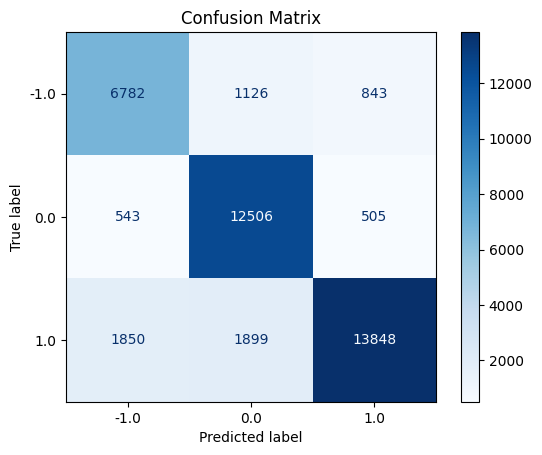

In [248]:
cm = confusion_matrix(
    labels,
    predictions
)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=encoder.classes_

)

disp.plot(
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png")

plt.show()

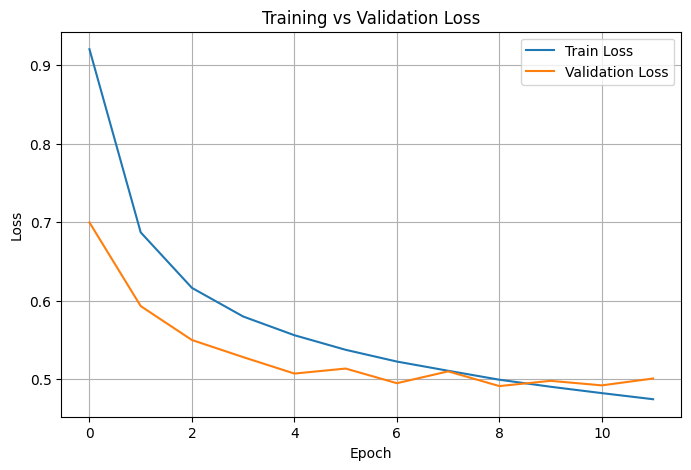

In [249]:
plt.figure(figsize=(8,5))

plt.plot(

    train_losses,

    label="Train Loss"

)

plt.plot(

    valid_losses,

    label="Validation Loss"

)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.grid(True)
plt.savefig("Training_vs_Validation Loss.png")
plt.show()

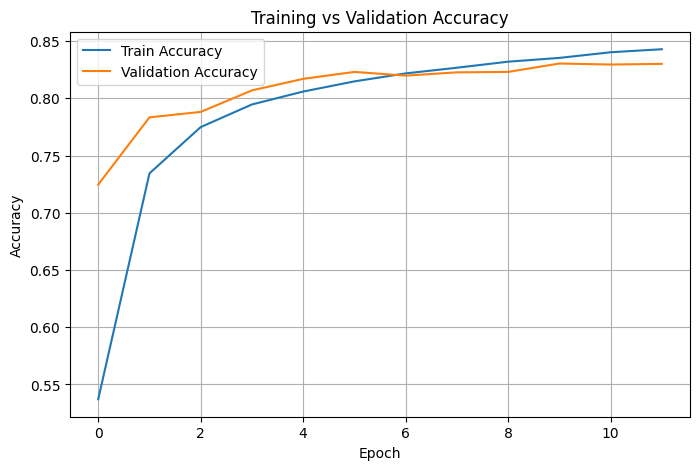

In [250]:
plt.figure(figsize=(8,5))

plt.plot(

    train_accuracies,

    label="Train Accuracy"

)

plt.plot(

    valid_accuracies,

    label="Validation Accuracy"

)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Training vs Validation Accuracy")

plt.legend()

plt.grid(True)
plt.savefig("Training_vs_Validation_Accuracy.png")

plt.show()

In [175]:
!pip install mlflow
!pip install boto3
!pip install awscli

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 76.4 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 74.0 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.3/121.3 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 969.1/969.1 kB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.9/214.9 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━

In [179]:
mlflow.set_tracking_uri("http://ec2-13-50-105-122.eu-north-1.compute.amazonaws.com:5000/")

mlflow.set_experiment(
    "Word2Vec_BiGRU_Text_Classification"
)


2026/07/27 12:29:04 INFO mlflow.tracking.fluent: Experiment with name 'Word2Vec_BiGRU_Text_Classification' does not exist. Creating a new experiment.


<Experiment: artifact_location='s3://zg-mlflow/4', creation_time=1785155344677, effective_trace_archival_retention=None, experiment_id='4', last_update_time=1785155344677, lifecycle_stage='active', name='Word2Vec_BiGRU_Text_Classification', tags={}, trace_location=None, workspace='default'>

In [251]:

try:

    with mlflow.start_run() as run:


        mlflow.set_tag(
            "model",
            "Bi-GRU"
        )

        mlflow.set_tag(
            "embedding",
            "Word2Vec"
        )

        mlflow.set_tag(
            "framework",
            "PyTorch"
        )

        mlflow.set_tag(
            "task",
            "Text Classification"
        )


        mlflow.log_param(
            "dataset_rows",
            len(df)
        )

        mlflow.log_param(
            "num_classes",
            NUM_CLASSES
        )

        mlflow.log_param(
            "vocab_size",
            VOCAB_SIZE
        )

        mlflow.log_param(
            "max_sequence_length",
            MAX_LEN
        )


        mlflow.log_param(
            "embedding_dim",
            EMBEDDING_DIM
        )

        mlflow.log_param(
            "word2vec_window",
            word2vec.window
        )

        mlflow.log_param(
            "word2vec_min_count",
            word2vec.min_count
        )

        mlflow.log_param(
            "word2vec_epochs",
            word2vec.epochs
        )



        mlflow.log_param(
            "architecture",
            "Embedding + BiGRU + Dense "
        )

        mlflow.log_param(
            "hidden_dim",
            HIDDEN_DIM
        )

        mlflow.log_param(
            "dropout",
            0.5
        )

        mlflow.log_param(
            "epochs",
            len(train_losses)
        )

        mlflow.log_param(
            "batch_size",
            BATCH_SIZE
        )

        mlflow.log_param(
            "learning_rate",
            LEARNING_RATE
        )

        mlflow.log_param(
            "optimizer",
            "AdamW"
        )

        mlflow.log_param(
            "loss_function",
            "CrossEntropyLoss"
        )
        


        mlflow.log_metric(
            "test_accuracy",
            accuracy
        )

        mlflow.log_metric(
            "test_precision",
            precision
        )

        mlflow.log_metric(
            "test_recall",
            recall
        )

        mlflow.log_metric(
            "test_f1_score",
            f1
        )
        for label, metrics in report.items():

            if isinstance(metrics, dict):

                for metric_name, value in metrics.items():

                    mlflow.log_metric(
                        f"{label}_{metric_name}",
                        value
                    )

        history = {

            "train_loss": train_losses,

            "valid_loss": valid_losses,

            "train_accuracy": train_accuracies,

            "valid_accuracy": valid_accuracies

        }


        with open(
            "training_history.json",
            "w"
        ) as f:

            json.dump(
                history,
                f,
                indent=4
            )


        mlflow.log_artifact("Training_vs_Validation_Accuracy.png")
        mlflow.log_artifact("Training_vs_Validation Loss.png")
        mlflow.log_artifact("/kaggle/working/confusion_matrix.png")



        df.to_csv(
            "dataset.csv",
            index=False
        )


        # Vocabulary artifact

        with open(
            "vocabulary.json",
            "w"
        ) as f:

            json.dump(
                word2idx,
                f
            )

        example_input = torch.randint(
                            0,
                            VOCAB_SIZE,
                            (1, MAX_LEN),
                            dtype=torch.long
                                        )
 
        mlflow.pytorch.log_model(
    pytorch_model=model,
    name="bigru_word2vec_model",
    input_example=example_input,
    serialization_format="pickle"   
)


        artifacts = [ "dataset.csv", "vocabulary.json",  "training_history.json"]


        for artifact in artifacts:

            mlflow.log_artifact(
                artifact
            )


        print(
            "MLflow Run ID:",
            run.info.run_id
        )


except Exception as e:

    print(
        "MLflow logging failed:",
        e
    )


finally:

    files = [ "dataset.csv","vocabulary.json","classification_report.json","training_history.json","loss_curve.png","accuracy_curve.png"

    ]


    for file in files:

        if os.path.exists(file):

            os.remove(file)

2026/07/27 13:09:11 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/07/27 13:09:11 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/07/27 13:09:26 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.25.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torchvision==0.25.0' without the loca

MLflow Run ID: 43c07ff724d14632a16c064bf8bce766
🏃 View run ambitious-ape-41 at: http://ec2-13-50-105-122.eu-north-1.compute.amazonaws.com:5000/#/experiments/4/runs/43c07ff724d14632a16c064bf8bce766
🧪 View experiment at: http://ec2-13-50-105-122.eu-north-1.compute.amazonaws.com:5000/#/experiments/4
